In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Loading NOAA Tornado dataset (1950-2023)...')
df = pd.read_csv('../data/tornadoes/noaa_tornadoes.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nYear range: {df["yr"].min()} - {df["yr"].max()}')
print(f'Total tornadoes: {len(df):,}')
print(f'\nMagnitude distribution (F/EF scale):')
print(df['mag'].value_counts().sort_index())
print(f'\nTop 10 states by tornado count:')
print(df['st'].value_counts().head(10))
print(f'\nInjuries total: {df["inj"].sum():,}')
print(f'Fatalities total: {df["fat"].sum():,}')

Loading NOAA Tornado dataset (1950-2023)...
Shape: (70022, 29)
Columns: ['om', 'yr', 'mo', 'dy', 'date', 'time', 'tz', 'st', 'stf', 'stn', 'mag', 'inj', 'fat', 'loss', 'closs', 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 'sg', 'f1', 'f2', 'f3', 'f4', 'fc']

Year range: 1950 - 2023
Total tornadoes: 70,022

Magnitude distribution (F/EF scale):
mag
-9     1024
 0    32218
 1    23782
 2     9767
 3     2585
 4      587
 5       59
Name: count, dtype: int64

Top 10 states by tornado count:
st
TX    9345
KS    4474
OK    4221
FL    3620
NE    3056
IA    2887
IL    2835
MS    2657
AL    2529
MO    2462
Name: count, dtype: int64

Injuries total: 98,372
Fatalities total: 6,221


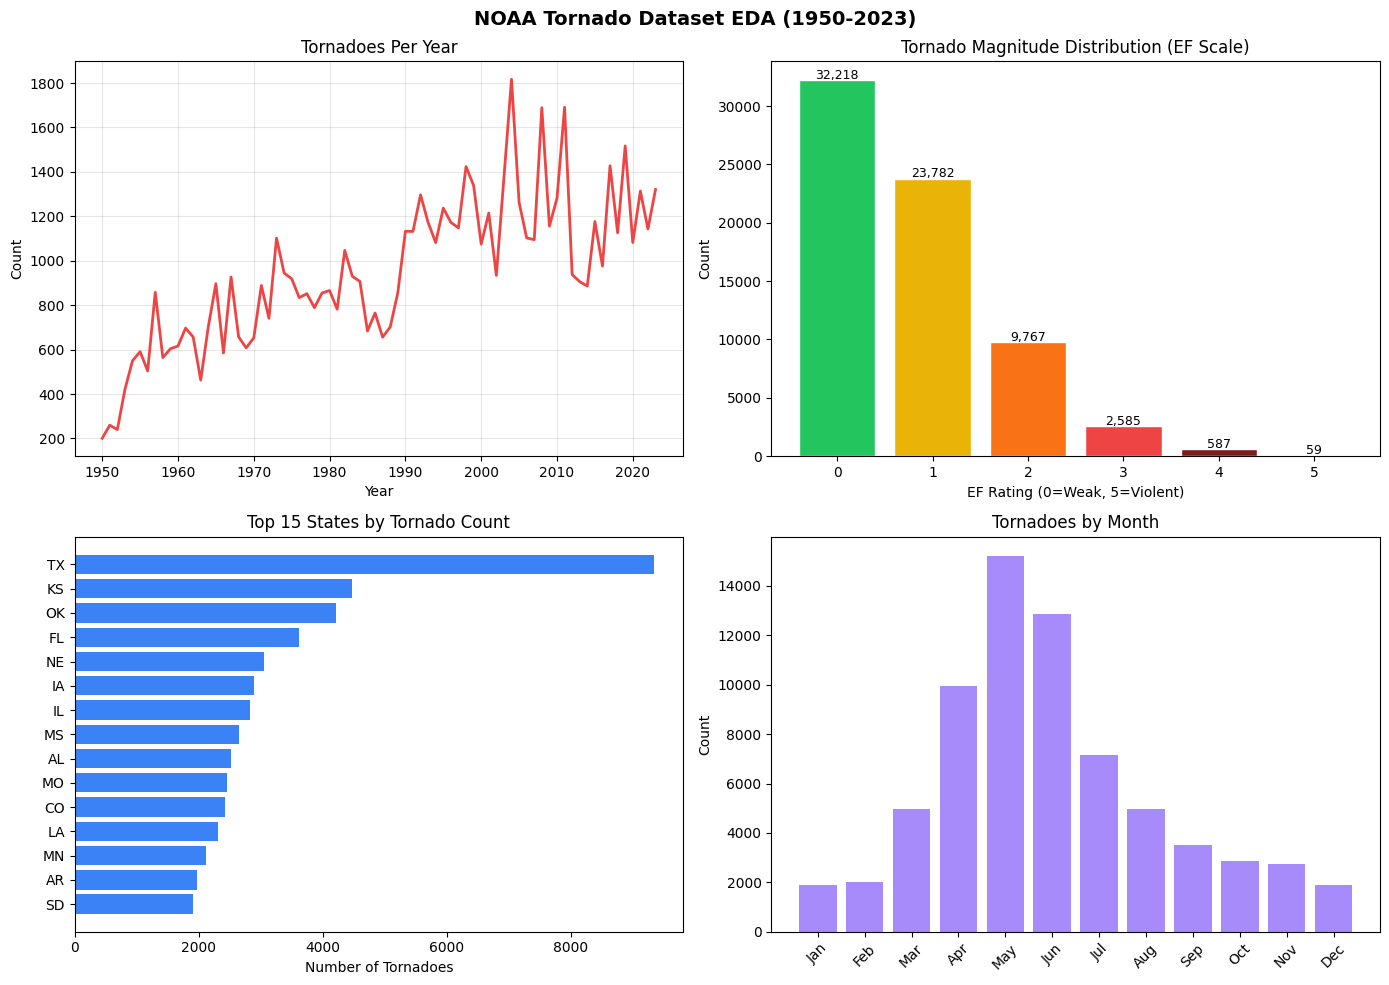

EDA plots saved.

=== KEY FINDINGS ===
Most tornado-prone state: TX (9,345 tornadoes)
Peak month: May (15,225 tornadoes)
EF5 tornadoes (most violent): 59
EF0 tornadoes (weakest): 32,218
Ratio EF0 to EF5: 546x more weak than violent

East coast states coverage:
  FL: 3,620 tornadoes
  GA: 1,898 tornadoes
  SC: 1,158 tornadoes
  NC: 1,472 tornadoes
  VA: 809 tornadoes
  MD: 398 tornadoes
  DE: 72 tornadoes
  NJ: 185 tornadoes
  NY: 493 tornadoes
  CT: 124 tornadoes
  RI: 16 tornadoes
  MA: 186 tornadoes
  NH: 97 tornadoes
  ME: 134 tornadoes


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NOAA Tornado Dataset EDA (1950-2023)', fontsize=14, fontweight='bold')

# 1. Tornadoes per year
yearly = df.groupby('yr').size()
axes[0,0].plot(yearly.index, yearly.values, color='#ef4444', linewidth=2)
axes[0,0].set_title('Tornadoes Per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# 2. Magnitude distribution
mag_counts = df[df['mag'] >= 0]['mag'].value_counts().sort_index()
colors = ['#22c55e', '#eab308', '#f97316', '#ef4444', '#7f1d1d', '#450a0a']
axes[0,1].bar(mag_counts.index, mag_counts.values,
              color=colors[:len(mag_counts)], edgecolor='white')
axes[0,1].set_title('Tornado Magnitude Distribution (EF Scale)')
axes[0,1].set_xlabel('EF Rating (0=Weak, 5=Violent)')
axes[0,1].set_ylabel('Count')
for i, (idx, val) in enumerate(mag_counts.items()):
    axes[0,1].text(idx, val + 100, f'{val:,}', ha='center', fontsize=9)

# 3. Top 15 states
top_states = df['st'].value_counts().head(15)
axes[1,0].barh(top_states.index[::-1], top_states.values[::-1], color='#3b82f6')
axes[1,0].set_title('Top 15 States by Tornado Count')
axes[1,0].set_xlabel('Number of Tornadoes')

# 4. Monthly distribution
monthly = df.groupby('mo').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,1].bar(range(1,13), monthly.values, color='#a78bfa')
axes[1,1].set_title('Tornadoes by Month')
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(month_names, rotation=45)
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/tornadoes/tornado_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

# Key findings
print('\n=== KEY FINDINGS ===')
print(f'Most tornado-prone state: {df["st"].value_counts().index[0]} ({df["st"].value_counts().iloc[0]:,} tornadoes)')
print(f'Peak month: {month_names[monthly.idxmax()-1]} ({monthly.max():,} tornadoes)')
print(f'EF5 tornadoes (most violent): {len(df[df["mag"]==5]):,}')
print(f'EF0 tornadoes (weakest): {len(df[df["mag"]==0]):,}')
print(f'Ratio EF0 to EF5: {len(df[df["mag"]==0]) / max(len(df[df["mag"]==5]),1):.0f}x more weak than violent')
print(f'\nEast coast states coverage:')
east_coast = ['FL', 'GA', 'SC', 'NC', 'VA', 'MD', 'DE', 'NJ', 'NY', 'CT', 'RI', 'MA', 'NH', 'ME']
for state in east_coast:
    count = len(df[df['st'] == state])
    if count > 0:
        print(f'  {state}: {count:,} tornadoes')